Found 300 files belonging to 2 classes.
Found 100 files belonging to 2 classes.
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.7956 - loss: 0.4225
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9183 - loss: 0.2011
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9394 - loss: 0.1520
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9628 - loss: 0.1174
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9722 - loss: 0.0954
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9822 - loss: 0.0788
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9872 - loss: 0.0690
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9883 - loss: 0.0607
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9917 - loss: 0.0514
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9939 - loss: 0.0470
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.995

[0.05981628969311714, 0.9700000286102295]

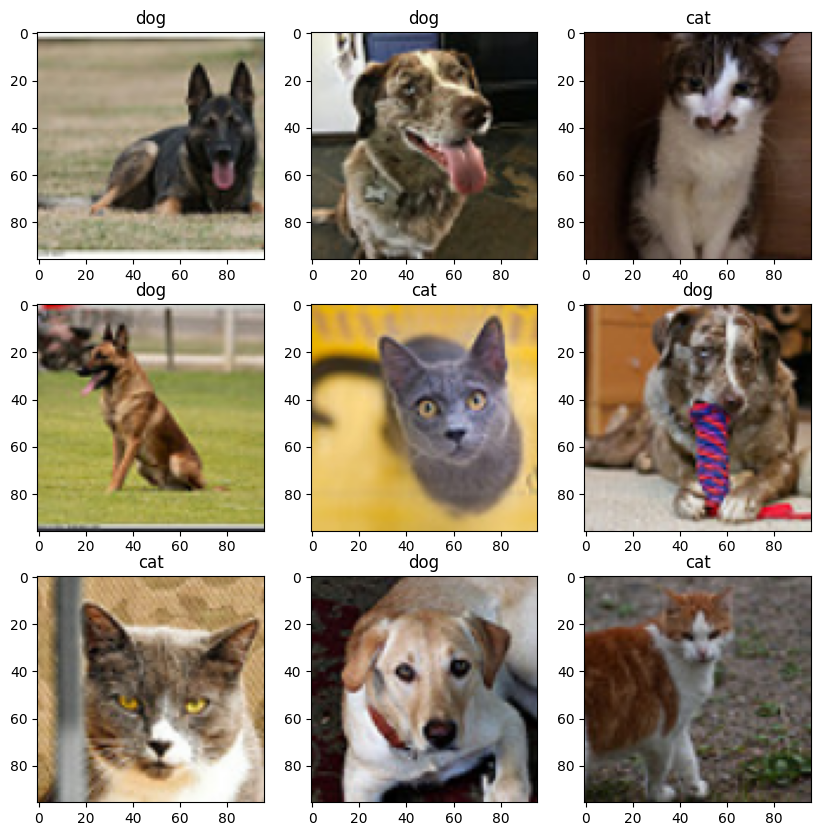

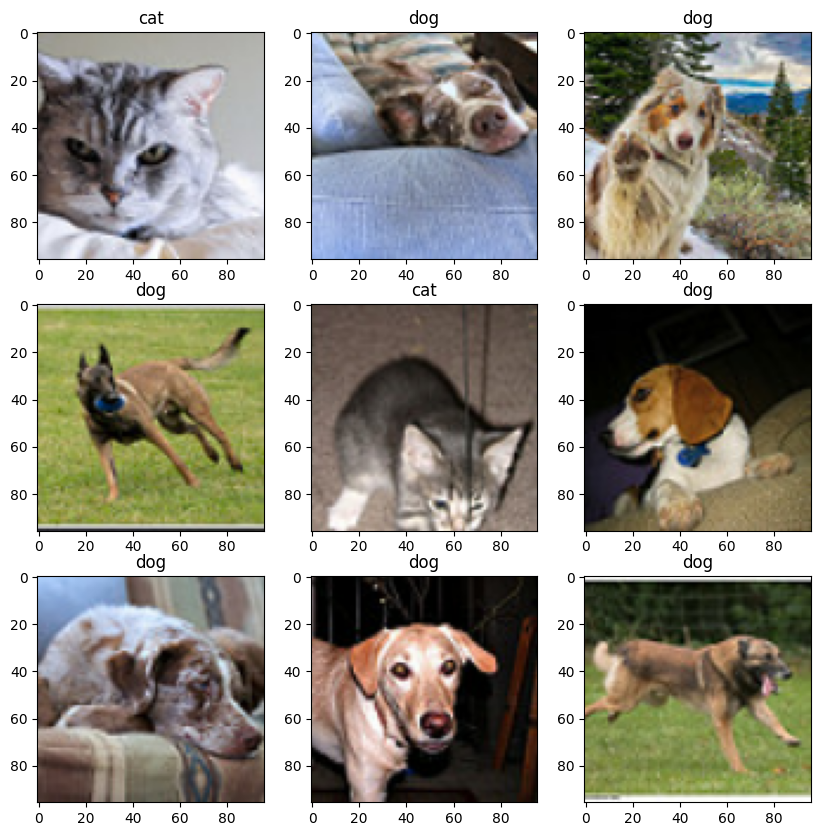

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# 訓練データを表示
def show_dataset_images(dataset, names, row=3):
    plt.figure(figsize=(10, 10))
    for images, labels in dataset.take(1):
        for i in range(row * 3):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(names[labels[i].numpy().astype("uint8")[0]])

# 画像の水増しをする関数の定義
def flip_left_right(image, label):   # 左右反転
    image = tf.image.flip_left_right(image)
    return image, label

def flip_up_down(image, label):      # 上下反転
    image = tf.image.flip_up_down(image)
    return image, label

def rot90(image, label):             # 反時計回りに90度回転
    image = tf.image.rot90(image)
    return image, label

def rot180(image, label):            # 反時計回りに180度回転
    image = tf.image.rot90(image, k=2)
    return image, label

def rot270(image, label):            # 反時計回りに270度回転
    image = tf.image.rot90(image, k=3)
    return image, label

# 訓練データとテストデータの画像を読み込む
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/train",
    image_size=(96, 96),
    label_mode="binary",
    batch_size=32,
    shuffle=True
)
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/test",
    image_size=(96, 96),
    label_mode="binary",
    batch_size=32,
    shuffle=False
)

# 分類名(cat, dog)リスト
class_names = train_dataset.class_names

# 訓練データの一部を表示して確認
show_dataset_images(dataset=train_dataset, names=class_names)

# 画像の水増し処理の実行
train_dataset_lr     = train_dataset.map(flip_left_right)
train_dataset_ud     = train_dataset.map(flip_up_down)
train_dataset_rot90  = train_dataset.map(rot90)
train_dataset_rot180 = train_dataset.map(rot180)
train_dataset_rot270 = train_dataset.map(rot270)

# 水増ししたデータを訓練データに追加する
train_dataset = train_dataset.concatenate(train_dataset_lr)
train_dataset = train_dataset.concatenate(train_dataset_ud)
train_dataset = train_dataset.concatenate(train_dataset_rot90)
train_dataset = train_dataset.concatenate(train_dataset_rot180)
train_dataset = train_dataset.concatenate(train_dataset_rot270)

# データをシャッフルする
train_dataset = train_dataset.shuffle(32)

# 訓練データの一部を表示して確認
show_dataset_images(dataset=train_dataset_shuffle, names=class_names)

# MobileNetV2モデルを作成する
input_layer = tf.keras.Input(shape=(96, 96, 3))   # 入力層
l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(input_layer)   # 前処理（正規化）をする層
base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(
    input_shape=(96, 96, 3),
    input_tensor=l_layer,
    include_top=False,
    weights="imagenet",
    pooling='avg'
)
base_model.trainable = False

# Dense層を追加する
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')

# base_modelに先ほどのDense層を追加したモデルを作成する
model = tf.keras.Sequential([
    base_model,
    output_layer
])

# modelをcompileする
model.compile(
    optimizer="adam",
    loss='binary_crossentropy',
    metrics=["accuracy"]
)

# modelに学習させる
model.fit(train_dataset, epochs=20)

# テストデータで分類を実行する
model.predict(test_dataset)

# evaluate()でモデルの性能を評価する
model.evaluate(test_dataset)
